# ViaWay Data Analysis
## GIX Cohort 6, Winter 2023

In [1]:
# Code excerpts from: 
# David Bondesson, OverLordGoldDragon
# Ridge extraction on signals with varying time-frequency characteristics.

%matplotlib notebook

import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ssqueezepy as sp
from ssqueezepy import ssq_cwt, ssq_stft, extract_ridges
from ssqueezepy.visuals import plot, imshow
import math
from tfridge_tracking import ridge_tracking as rt
import sklearn.neighbors

dataset = os.path.abspath("")
print(dataset)

def return_file(file):
    return os.path.join(dataset, file)

%ls # Show current directory's contents.

/Users/aqibahmed/Desktop/ViaWay
README.md
ViaWay Data Analysis.ipynb
cad/
data/
defect_bridge_readings_with_vibrations_1/
defect_bridge_readings_with_vibrations_1.zip
defect_bridge_readings_with_vibrations_2/
defect_bridge_readings_with_vibrations_2.zip
defect_bridge_readings_without_vibrations_1/
defect_bridge_readings_without_vibrations_1.zip
defect_bridge_readings_without_vibrations_2/
defect_bridge_readings_without_vibrations_2.zip
electronics/
experimental_data/
signal processing/
signal_processing_results/
tfridge_tracking/


In [2]:
def tf_transforms(x, t, wavelet='morlet', window=None, padtype='wrap',
                  penalty=.5, n_ridges=2, cwt_bw=15, stft_bw=15,
                  ssq_cwt_bw=4, ssq_stft_bw=4):
    kw_cwt  = dict(t=t, padtype=padtype)
    kw_stft = dict(fs=1/(t[1] - t[0]), padtype=padtype, flipud=1)
    Twx, Wx, ssq_freqs_c, scales, *_ = ssq_cwt(x,  wavelet, **kw_cwt)
    Tsx, Sx, ssq_freqs_s, Sfs, *_    = ssq_stft(x, window,  **kw_stft)
    Sx, Sfs = Sx[::-1], Sfs[::-1]

    ckw = dict(penalty=penalty, n_ridges=n_ridges, transform='cwt')
    skw = dict(penalty=penalty, n_ridges=n_ridges, transform='stft')
    cwt_ridges      = extract_ridges(Wx,  scales,      bw=cwt_bw,      **ckw)
    ssq_cwt_ridges  = extract_ridges(Twx, ssq_freqs_c, bw=ssq_cwt_bw,  **ckw)
    stft_ridges     = extract_ridges(Sx,  Sfs,         bw=stft_bw,     **skw)
    ssq_stft_ridges = extract_ridges(Tsx, ssq_freqs_s, bw=ssq_stft_bw, **skw)

    viz(x, Wx,  cwt_ridges,      scales,      ssq=0, transform='cwt',  show_x=1)
    viz(x, Twx, ssq_cwt_ridges,  ssq_freqs_c, ssq=1, transform='cwt',  show_x=0)
    viz(x, Sx,  stft_ridges,     Sfs,         ssq=0, transform='stft', show_x=0)
    viz(x, Tsx, ssq_stft_ridges, ssq_freqs_s, ssq=1, transform='stft', show_x=0)

In [3]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / N

In [4]:
# TODO: Function to downsample signal to 100 Hz.
def kalman_filter(x, N):
    # intial parameters
    n_iter = 50
    sz = (n_iter,) # size of array
    x = -0.37727 # truth value (typo in example at top of p. 13 calls this z)
    z = np.random.normal(x, 0.1, size=sz) # observations (normal about x, sigma=0.1)

    Q = 1e-5 # process variance

    # allocate space for arrays
    xhat = np.zeros(sz)      # a posteri estimate of x
    P = np.zeros(sz)         # a posteri error estimate
    xhatminus = np.zeros(sz) # a priori estimate of x
    Pminus = np.zeros(sz)    # a priori error estimate
    K = np.zeros(sz)         # gain or blending factor

    R = 0.1**2 # estimate of measurement variance, change to see effect

    # intial guesses
    xhat[0] = 0.0
    P[0] = 1.0

    for k in range(1,n_iter):
        # time update
        xhatminus[k] = xhat[k-1]
        Pminus[k] = P[k-1]+Q

        # measurement update
        K[k] = Pminus[k] / ( Pminus[k] + R )
        xhat[k] = xhatminus[k] + K[k] * (z[k] - xhatminus[k])
        P[k] = (1 - K[k]) * Pminus[k]

In [5]:
def moving_average(a, n = 3) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n



In [6]:
# read_file = pd.read_excel (r'./data/.//Acceleration without g 2023-02-27 09-51-54.xls')
# read_file.to_csv (r'./sep_accel_data.csv', index = None, header=True)

# accel_data = pd.read_csv('./bridge_data_ground_truth.csv')
accel_data = pd.read_csv('./signal processing/ViaWay/data/python-mqtt-371678745973.496969.csv')
accel_data

,time,accel_z
0,1.678746e+09,4
1,1.678746e+09,4
2,1.678746e+09,4
3,1.678746e+09,3
4,1.678746e+09,4
...,...,...
784,1.678746e+09,3
785,1.678746e+09,4
786,1.678746e+09,4
787,1.678746e+09,5


In [7]:
# Extract Linear Acceleration z (m/s^2)column:
# z_acc = accel_data["Linear Acceleration z (m/s^2)"]
z_acc = accel_data["accel_z"]

# z_acc = moving_average(np.array(z_acc))
z_acc

0      4
1      4
2      4
3      3
4      4
      ..
784    3
785    4
786    4
787    5
788    5
Name: accel_z, Length: 789, dtype: int64

In [8]:
# TODO: 
# 0. Resample date at 100 Hz. --> PENDING
# 1. Morlet wavelet transform --> DONE
# 2. Frequency Ridge Extraction --> DONE
# 3. Histogram  of extracted ridges --> DONE
# 4. Kernel density estimation on histogram from (3) --> DONE
# 5. 


# Begin by visualizing the z-axis acceleration:
# z_acc = sample_df[["Timestamp", "accelZ"]]
# z_acc.plot(x = "Timestamp", y = "accelZ", kind = "line", figsize=(9, 8), xlabel = None)
# plt.show()

def get_bridge_coordinates(lat, lon):
        lat1 = lat[0]
        lon1 = lon[0]
        distances = []
        distances.append(0)
        R = 6371000                               # radius of Earth in meters
        
        for i in range(1, len(lat)):
            lat2 = lat[i]
            lon2 = lon[i]
            
            phi_1 = math.radians(lat1)
            phi_2 = math.radians(lat2)
            

            delta_phi = math.radians(lat2 - lat1)
            delta_lambda = math.radians(lon2-  lon1)
 
            a = math.sin(delta_phi / 2.0)**2 + math.cos(phi_1) * math.cos(phi_2) * math.sin(delta_lambda / 2.0)**2
            c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
        
            meters = R * c                         # output distance in meters
            distances.append(meters)
            lat1 = lat2
            lon1 = lon2
#         self.km=self.meters/1000.0              # output distance in kilometers
#         self.miles=self.meters*0.000621371      # output distance in miles
#         self.feet=self.miles*5280               # output distance in feet
        return distances

# coordinates = sample_df[["Lat", "Long"]]
# # display(coordinates)

# latitudes = np.array(coordinates[["Lat"]])
# longitudes = np.array(coordinates[["Long"]])

# distances = get_bridge_coordinates(latitudes, longitudes)
# print(distances)
# plt.figure()
# plt.plot(distances)
# plt.show()
# print(len(distances))

In [9]:
z_acc

0      4
1      4
2      4
3      3
4      4
      ..
784    3
785    4
786    4
787    5
788    5
Name: accel_z, Length: 789, dtype: int64

In [10]:
def viz(x, Tx, Wx):
    plt.title("Synchrosqueezed Wavelet Transform [Morlet Window] Assumed Ground Truth")
    plt.xlabel("Time [samples]")
    plt.ylabel("Time Scales [1/Hz]")
    
    plt.imshow(np.abs(Tx), aspect='auto', cmap=plt.cm.nipy_spectral_r)
#     plt.show()
#     plt.imshow(np.abs(Tx), aspect='auto', vmin=0, vmax=.2, cmap = plt.cm.nipy_spectral_r)
    plt.show()

#%%# Define signal ####################################

# N = 2048
# t = np.linspace(0, 10, N, endpoint=False)
# xo = np.cos(2 * np.pi * 2 * (np.exp(t / 2.2) - 1))
# xo += xo[::-1]  # add self reflected
# x = xo + np.sqrt(2) * np.random.randn(N)  # add noise

# plt.plot(xo); plt.show()
# plt.plot(x);  plt.show()

# #%%# CWT + SSQ CWT ####################################
# Twxo, Wxo, *_ = ssq_cwt(xo)
# viz(xo, Twxo, Wxo)

# Twx, Wx, *_ = ssq_cwt(x)
# viz(x, Twx, Wx)

# #%%# STFT + SSQ STFT ##################################
# Tsxo, Sxo, *_ = ssq_stft(xo)
# viz(xo, np.flipud(Tsxo), np.flipud(Sxo))

# Tsx, Sx, *_ = ssq_stft(x)
# viz(x, np.flipud(Tsx), np.flipud(Sx))

In [11]:
# z_acc_arr = np.array(z_acc["accelZ"])
# z_accel = np.array(z_acc)
t = np.linspace(0, 5, len(z_acc), endpoint=False)

# plt.figure()
# plt.plot(t, z_accel)
# plt.show()

# print(len(z_accel))
z_acc.shape


(789,)

<IPython.core.display.Javascript object>


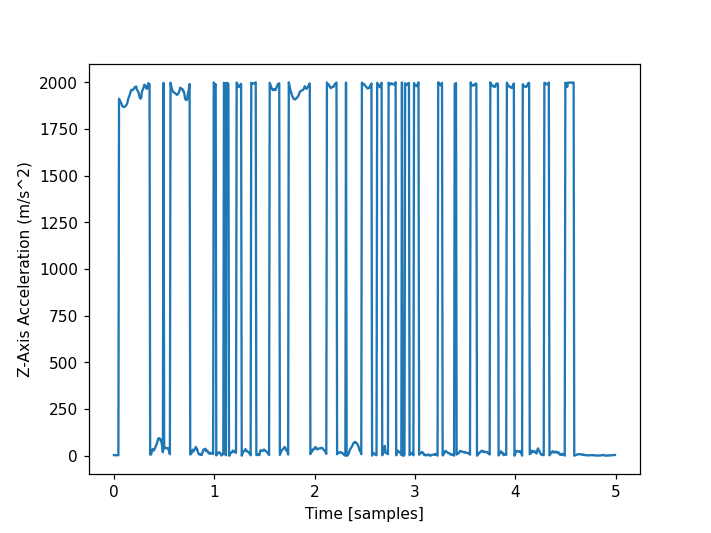

In [12]:
plt.figure()
plt.plot(t, z_acc)
plt.ylabel("Z-Axis Acceleration (m/s^2)")
plt.xlabel("Time [samples]")
plt.show()

In [13]:
z_acc = np.array(z_acc).flatten()

In [14]:
# Here, x will be the original accel_z signal, 
N, f = len(z_acc), 0.5
padtype = 'wrap'
penalty = 20

t  = np.linspace(0, 10, N, endpoint=True)

# tf_transforms(z_acc, t, n_ridges=3, padtype=padtype, stft_bw=4, ssq_stft_bw=4,
#               penalty=penalty)

# TODO: 
Twz, Wz, ssq_freqs_c, scales, *_ = ssq_cwt(z_acc, 'morlet')
plt.figure()
viz(z_acc, Twz, Wz)
plt.show()

<IPython.core.display.Javascript object>

In [ ]:
# Extract z_accel data as array
# plt.figure()

# print(len(z_acc_arr), lSen(t))
# print(z_acc_arr)
# print(t)

ssq_freqs_c

# Twz, Wz, *_ = ssq_cwt(z_accel)
# viz(z_accel, Twz, Wz)

In [16]:
Twz

array([[ 3.8989501e+00+2.2575498e-02j, -4.7196326e+00-6.0722697e-01j,
         5.2203012e+00+1.0522346e+00j, ...,
        -2.9692845e-02+1.1741411e-01j,  2.9677231e-02-1.2056028e-01j,
        -2.9304126e-02+1.2045556e-01j],
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
        -8.5158052e-04+8.5818674e-03j, -6.4413896e-04-4.6599782e-03j,
         5.2023586e-04+1.3365335e-03j],
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
         4.5900734e-04+2.0936683e-03j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j],
       ...,
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
         0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j],
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00

In [17]:
# Twz, Wz, *_ = ssq_cwt(z_accel)
# viz(z_accel, Twz, Wz)

In [18]:
Twz.shape

(238, 789)

In [19]:
Wz.shape

(238, 789)

In [20]:
# Extract from sampled dataset:
# plt.figure()
# plt.plot(t, np.transpose(Twz))
# plt.show()

In [21]:
# Frequency ridge detection
# scales = np.exp(np.linspace(np.log(1.51),np.log(622.207),nbr_scales))
# cwtmatr, freqs = pywt.cwt(signal,scales,'cmor2.0-1.0')
# nbr_scales=269
# scales=np.exp(np.linspace(np.log(1.51),np.log(622.207),nbr_scales))
# penalty = 2.0
# cwtmatr, freqs = pywt.cwt(sweep_sig,scales,'cmor2.0-1.5')

# # CWT example
# Energy,ridge_idx, _ = rt.extract_fridges(cwtmatr, scales, penalty, num_ridges = 50, BW = 25)



In [22]:
def visualize(x, Tf, ridge_idxs, yticks = None, ssq = False, transform = 'cwt', show_x = True):
    if show_x:
        plot(x, title="x(t)", show = 1,
             xlabel="Time [samples]", ylabel="Signal Amplitude [A.U.]")

    ylabel = ("Frequency scales [1/Hz]" if (transform == 'cwt' and not ssq) else
              "Frequencies [Hz]")
    title = "abs({}{}) w/ ridge_idxs for Assumed Ground Truth".format("SSQ_" if ssq else "",
                                             transform.upper())

    ikw = dict(abs = 1, cmap = plt.cm.nipy_spectral_r, yticks = yticks, title = title)
    pkw = dict(linestyle = '--', color = 'k', xlabel = "Time [samples]", ylabel = ylabel,
               xlims=(0, Tf.shape[1]))

    imshow(Tf, **ikw, show = 0)
    plot(ridge_idxs, **pkw, show = 1)

<IPython.core.display.Javascript object>


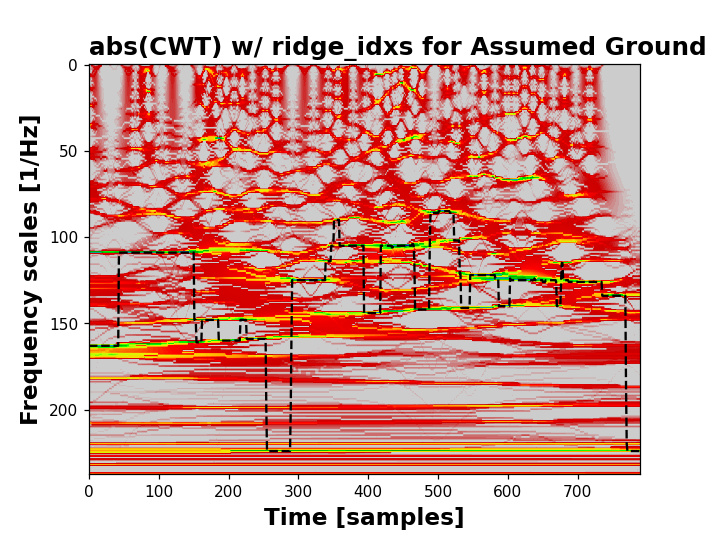

In [23]:
# plt.figure()
# visualize(z_acc, Twz, ridge_idx)
# viz(z_acc, Twz, ridge_idx)

# Ridge Detection: 
ssq_cwt_ridge_idxs = extract_ridges(Twz, ssq_freqs_c, bw = 2, transform = 'cwt', n_ridges = 5)

plt.figure()
visualize([], Twz, [x[0] for x in ssq_cwt_ridge_idxs])

In [24]:
ssq_cwt_ridge_idxs.shape

(789, 5)

In [25]:
ssq_cwt_ridges_first = np.array([x[1] for x in ssq_cwt_ridge_idxs])
ssq_cwt_ridges_first

array([109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 163, 163, 163, 163, 163, 163, 163, 163, 163,
       163, 163, 163, 163, 163, 163, 162, 162, 162, 162, 162, 162, 162,
       162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162,
       162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162,
       162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162,
       162, 162, 162, 162, 162, 162, 162, 162, 163, 162, 162, 162, 162,
       162, 162, 162, 162, 162, 161, 161, 161, 161, 161, 161, 161, 161,
       161, 161, 161, 161, 161, 161, 161, 161, 161, 161, 161, 161, 161,
       161, 161, 161, 161, 161, 161, 161, 161, 161, 161, 161, 148, 148,
       148, 148, 148, 148, 148, 148, 109, 109, 108, 108, 108, 108, 108,
       108, 108, 108, 108, 108, 108, 108, 108, 108,  74,  74,  7

In [26]:
# Here, x will be the original accel_z signal, 
N, f = len(z_acc), 0.5
padtype = 'wrap'
penalty = 20

# t  = np.linspace(0, 10, N, endpoint=True)

# tf_transforms(z_acc, t, n_ridges=3, padtype=padtype, stft_bw=4, ssq_stft_bw=4,
#               penalty=penalty)

# TODO: 
# Twx, Wx, ssq_freqs_c, scales, *_ = ssq_cwt(z_accel, 'morlet')

# viz(z_accel, Twx, Wx)

<IPython.core.display.Javascript object>


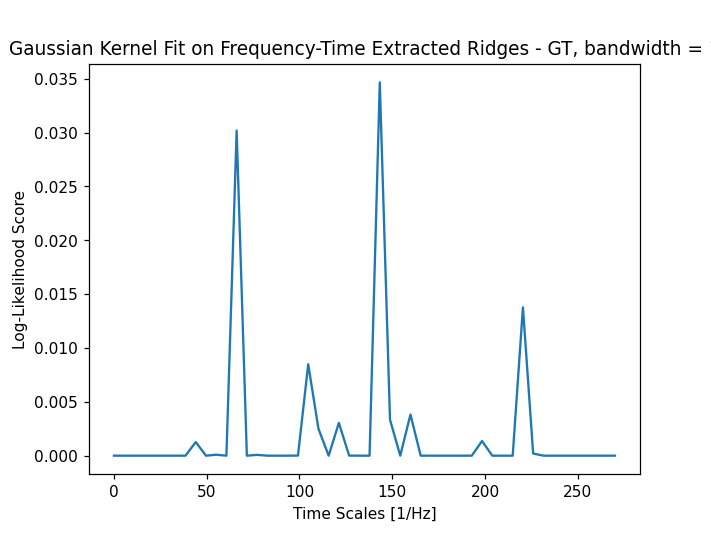

In [27]:
# TODO: Produce histogram for frequency - count
# Gaussian KDE

kde_ridge_data = ssq_cwt_ridges_first.reshape(-1, 1)
N = len(kde_ridge_data)
x_plot = np.linspace(0, 270)
# x_plot = [1/x if x != 0 else 0 for x in x_plot]
# X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
kde = sklearn.neighbors.KernelDensity(kernel = "gaussian", bandwidth = 0.5).fit(kde_ridge_data)
log_dens = kde.score_samples(np.array(x_plot).reshape(-1, 1))

plt.figure()
# plt.hist(np.exp(log_dens), fc='gray', histtype='stepfilled', alpha=1)
plt.plot(x_plot, np.exp(log_dens))
plt.title("Gaussian Kernel Fit on Frequency-Time Extracted Ridges - GT, bandwidth = 1")
plt.xlabel("Time Scales [1/Hz]")
plt.ylabel("Log-Likelihood Score") 
plt.show()

In [28]:
# TODO: 
# ssq_cwt_ridges  = extract_ridges(Twz, ssq_freqs_c, bw = 4, transform = 'cwt', n_ridges = 50)
# visualize(z_accel, Twz, ssq_cwt_ridges,  ssq_freqs_c, ssq=1, transform='cwt',  show_x=0)

# TODO: 
# Function to extract top n maxima from Extracted Ridge Kernel Density Estimate

def get_max_log_scores(x, n):
    # Base case: len(x) == 0:
    if len(x) == 0:
        return []
    elif len(x) < n:
        return sorted(x, reverse = True)
    else:
        return sorted(x, reverse = True)[:n]
    
get_max_log_scores(np.exp(log_dens), 3)

[0.03465884641141065, 0.030182220778445262, 0.013769308347062064]